In [1]:
import os
import sys
import time
import numpy as np
import xarray as xr
from glob import glob

In [2]:
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [4]:
import cmaps

In [5]:
sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [6]:
fig_keys = {
    'dpi': 150, 
    'orientation':'portrait', 
    'bbox_inches':'tight', 
    'pad_inches':0.1, 
    'transparent':False
}

In [7]:
need_publish = False

if need_publish:
    dpi_ = fig_keys['dpi']
else:
    dpi_ = 75

In [8]:
verif_years = np.arange(2010, 2020)

In [9]:
fn_crps = f'/glade/derecho/scratch/ksha/EPRI_data/PP_verif/TMAX_EMOS_{verif_years[0]}_{verif_years[-1]}.zarr'
ds_crps = xr.open_zarr(fn_crps)

In [10]:
crps_raw  = ds_crps['CRPS_CESM']
crps_emos = ds_crps['CRPS_EMOS']
 
# Spatial maps: average over init_time and lead_time
raw_map  = crps_raw.mean(dim=['init_time', 'lead_time'])    # (lat, lon)
emos_map = crps_emos.mean(dim=['init_time', 'lead_time'])
diff_map = raw_map - emos_map                                # positive = EMOS better
skill_map = 1.0 - emos_map / raw_map                        # CRPSS
 
# Temporal: average over lat, lon, init_time → per lead_time
raw_by_lead  = crps_raw.mean(dim=['init_time', 'lat', 'lon'])   # (lead_time,)
emos_by_lead = crps_emos.mean(dim=['init_time', 'lat', 'lon'])
 
# Annual means (10 forecast years)
raw_annual  = raw_by_lead.values.reshape(10, 365).mean(axis=1)
emos_annual = emos_by_lead.values.reshape(10, 365).mean(axis=1)
 
# Monthly rolling mean for smoother temporal plot
def rolling_mean(arr, window=30):
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='same')
 
raw_smooth  = rolling_mean(raw_by_lead.values)
emos_smooth = rolling_mean(emos_by_lead.values)
 
# Per init-year
raw_by_init  = crps_raw.mean(dim=['lead_time', 'lat', 'lon'])   # (init_time,)
emos_by_init = crps_emos.mean(dim=['lead_time', 'lat', 'lon'])
 
# Zonal mean by lead year: (10, lat)
raw_zonal  = crps_raw.mean(dim=['init_time', 'lon']).values.reshape(10, 365, -1).mean(axis=1)
emos_zonal = crps_emos.mean(dim=['init_time', 'lon']).values.reshape(10, 365, -1).mean(axis=1)
skill_zonal = 1.0 - emos_zonal / np.maximum(raw_zonal, 1e-10)
 
lat = ds_crps.lat.values
lon = ds_crps.lon.values
init_years = ds_crps.init_time.values

In [11]:
doy_raw  = raw_by_lead.values.reshape(10, 365).mean(axis=0)   # (365,)
doy_emos = emos_by_lead.values.reshape(10, 365).mean(axis=0)
# doy_skill = 1.0 - doy_emos / np.maximum(doy_raw, 1e-10)

In [12]:
scale_param = '110m'

PROVINCE = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale=scale_param,
    facecolor='none')

def map_gridline_opt(ax):
    ax.add_feature(cfeature.BORDERS.with_scale(scale_param), linestyle='-', linewidth=1.0, zorder=7)
    # ax.add_feature(PROVINCE, edgecolor='k', linestyle='-', linewidth=1.5, zorder=7)
    ax.add_feature(cfeature.COASTLINE.with_scale(scale_param), edgecolor='k', linewidth=1.0, zorder=5)
    ax.spines['geo'].set_linewidth(2.5)
    return ax

In [13]:
emos_map_np = emos_map.values
skill_map_np = skill_map.values
raw_by_init_np = raw_by_init.values
emos_by_init_np = emos_by_init.values

In [14]:
cmap_t2 = cmaps.wgne15
cmap_skill = cmaps.amwg_blueyellowred # plt.cm.RdBu_r cmaps.CBR_coldhot #

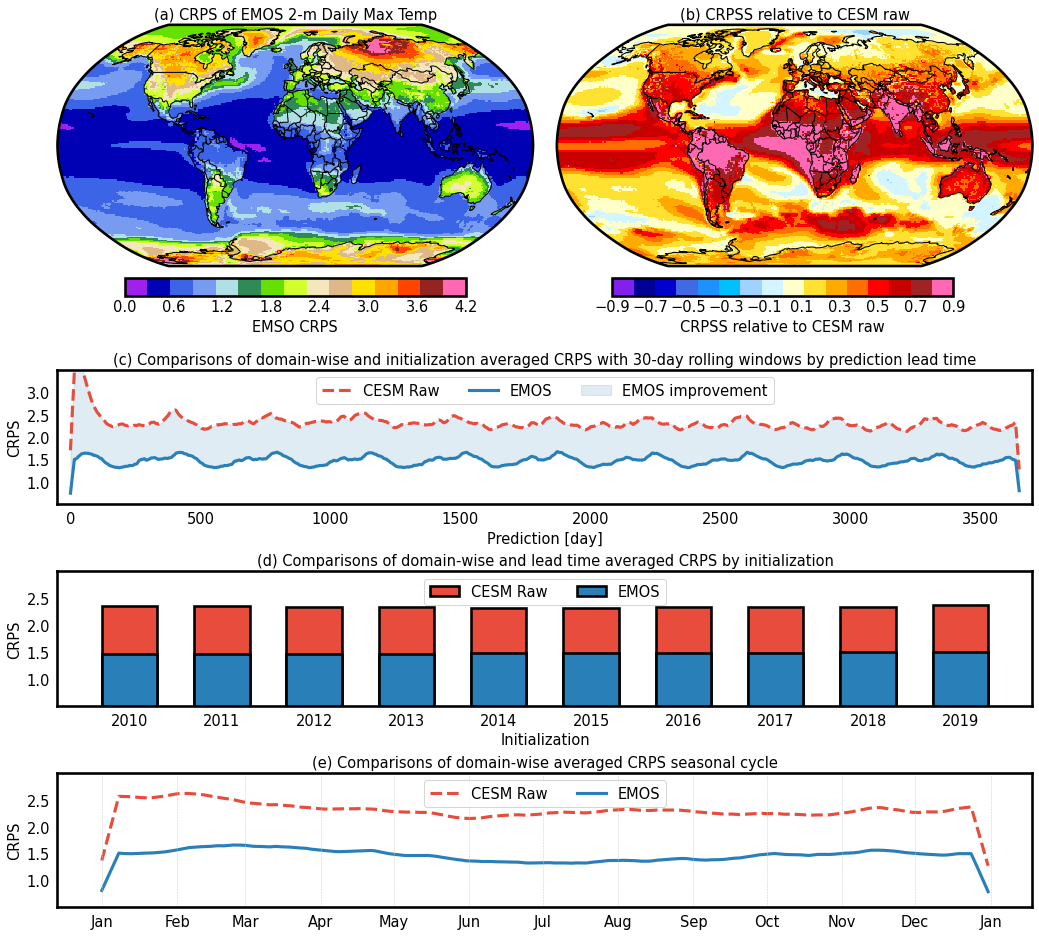

In [15]:
proj = ccrs.Robinson()
data_proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(13, 13), dpi=dpi_)
h_ratio = [2,]+list(0.7*np.array([0.075, 0.9, 0.45, 0.9, 0.45, 0.9]))
gs = gridspec.GridSpec(7, 2, height_ratios=h_ratio, width_ratios=[1,]*2)

AX_maps = []
AX_maps.append(plt.subplot(gs[0, 0], projection=proj))
AX_maps.append(plt.subplot(gs[0, 1], projection=proj))

ax_lead = plt.subplot(gs[2, :])
ax_init = plt.subplot(gs[4, :])
ax_season = plt.subplot(gs[6, :])

plt.subplots_adjust(0, 0, 1, 1, hspace=0.0, wspace=0.05)

for ax in AX_maps:
    ax = map_gridline_opt(ax)

for ax in [ax_lead, ax_init, ax_season]:
    ax = gu.ax_decorate_box(ax)

# ====================================================================================================== #
vmax_raw = 4.2 # np.nanpercentile(emos_map_np, 99.9)
CS1 = AX_maps[0].pcolormesh(
    lon, lat, emos_map_np, cmap=cmap_t2, vmin=0, vmax=vmax_raw, transform=data_proj
)

vmax_skill = 0.9
CS2 = AX_maps[1].pcolormesh(
    lon, lat, skill_map_np, cmap=cmap_skill, vmin=-1.0*vmax_skill, vmax=vmax_skill, transform=data_proj
)

ax_base1 = fig.add_axes([0.069, 0.585, 0.35, 0.06])
ax_base1.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax1 = inset_axes(ax_base1, height='30%', width='100%', borderpad=0, loc=2)
CBar1 = plt.colorbar(CS1, orientation='horizontal', cax=cax1)
CBar1.ax.tick_params(axis='x', labelsize=14, direction='in', length=0)
CBar1.outline.set_linewidth(2.5)
CBar1.set_ticks([0, 0.6, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2])
CBar1.ax.set_xlabel('EMSO CRPS', fontsize=14)

ax_base2 = fig.add_axes([0.069+0.5, 0.585, 0.35, 0.06])
ax_base2.tick_params(
    axis='both', left=False, top=False, right=False, bottom=False, 
    labelleft=False, labeltop=False, labelright=False, labelbottom=False
)
cax2 = inset_axes(ax_base2, height='30%', width='100%', borderpad=0, loc=2)
CBar2 = plt.colorbar(CS2, orientation='horizontal', cax=cax2)
CBar2.ax.tick_params(axis='x', labelsize=14, direction='in', length=0)
CBar2.outline.set_linewidth(2.5)
CBar2.set_ticks([-0.9, -0.7, -0.5, -0.3, -0.1, 0.1, 0.3, 0.5, 0.7, 0.9])
CBar2.ax.set_xlabel('CRPSS relative to CESM raw', fontsize=14)

# ====================================================================================================== #

lead_days = np.arange(len(raw_smooth))
ax_lead.plot(lead_days, raw_smooth, color='#E74C3C', linewidth=3, linestyle='--', label='CESM Raw')
ax_lead.plot(lead_days, emos_smooth, color='#2980B9', linewidth=3, label='EMOS')
ax_lead.fill_between(
    lead_days, emos_smooth, raw_smooth,
    where=raw_smooth > emos_smooth,
    color='#2980B9', alpha=0.15, label='EMOS improvement')

ax_lead.set_xlim([0-50, 3650+50])
ax_lead.set_ylim([0.5, 3.5])
ax_lead.set_yticks([1.0, 1.5, 2.0, 2.5, 3.0])
ax_lead.set_ylabel('CRPS', fontsize=14)
ax_lead.set_xlabel('Prediction [day]', fontsize=14)
ax_lead.legend(loc='upper center', ncols=3, fontsize=14)
ax_lead.tick_params(labelleft=True, labelbottom=True, labelsize=14)

# ====================================================================================================== #
ax_init.bar(verif_years, raw_by_init_np, width=0.6, facecolor='#E74C3C', linewidth=2.5, edgecolor='k', label='CESM Raw')
ax_init.bar(verif_years, emos_by_init_np, width=0.6, facecolor='#2980B9', linewidth=2.5, edgecolor='k', label='EMOS')
ax_init.set_ylabel('CRPS', fontsize=14)
ax_init.set_xticks(verif_years)
ax_init.set_ylim([0.5, 3.0])
ax_init.set_yticks([1.0, 1.5, 2.0, 2.5])
ax_init.set_ylabel('CRPS', fontsize=14)
ax_init.set_xlabel('Initialization', fontsize=14)
ax_init.legend(loc='upper center', ncols=2, fontsize=14)
ax_init.tick_params(labelleft=True, labelbottom=True, labelsize=14)

# ====================================================================================================== #
x_mon = np.arange(1, 366)
ax_season.plot(x_mon, rolling_mean(doy_raw, 15), color='#E74C3C', linewidth=3, linestyle='--', label='CESM Raw')
ax_season.plot(x_mon, rolling_mean(doy_emos, 15), color='#2980B9', linewidth=3, label='EMOS')
ax_season.legend(loc='upper center', ncols=2, fontsize=14)

# Month boundaries
month_starts = np.array([0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365]) + 1
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan']
for m in month_starts:
    ax_season.axvline(m, color='0.8', linewidth=0.5, linestyle='--')
    
ax_season.set_ylim([0.5, 3.0])
ax_season.set_yticks([1.0, 1.5, 2.0, 2.5])
ax_season.set_ylabel('CRPS', fontsize=14)
ax_season.set_xticks(month_starts)
ax_season.set_xticklabels(month_labels, fontsize=10)
ax_season.tick_params(labelleft=True, labelbottom=True, labelsize=14)

AX_maps[0].set_title('(a) CRPS of EMOS 2-m Daily Max Temp', fontsize=14)
AX_maps[1].set_title('(b) CRPSS relative to CESM raw', fontsize=14)
ax_lead.set_title('(c) Comparisons of domain-wise and initialization averaged CRPS with 30-day rolling windows by prediction lead time', fontsize=14)
ax_init.set_title('(d) Comparisons of domain-wise and lead time averaged CRPS by initialization', fontsize=14)
ax_season.set_title('(e) Comparisons of domain-wise averaged CRPS seasonal cycle', fontsize=14)

ax_base1.set_axis_off()
ax_base2.set_axis_off()